# Работа по теме "Временные ряды"

## Описание

Работа предполагает самостоятельное исследование данных и построение моделей прогнозирования временных рядов.

Основная задача работы - научиться работать с временными рядами, прогнозировать их.

Предлагается один набор данных.

Примерные критерии оценки:
- представленные данные изучены и описаны;
- данные предобработаны при необходимости, разделены на выборки;
- показано исследование данных на предмет автокорреляций, оптимальных лагов;
- рассмотрено не менее двух моделей прогнозирования;
- рассмотрены различные метрики для оценки, при описании результатов метрики верно интерпретированы.

В результате необходимо получить наилучшую модель прогнозирования временных рядов, при этом основную метрику разрешается выбрать самостоятельно, объяснив свой выбор. Также должен быть показан весь процесс исследования данных и настройки моделей.

## Импорт библиотек

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

# Температурные изменения

Набор данных `MLTempDataset.csv` содержит показания комнатной температуры в зависимости от времени.

Требуется построить модель, позволяющую прогнозировать температуру.

In [3]:
df = pd.read_csv('MLTempDataset.csv', parse_dates=['Datetime'])
df.set_index('Datetime', inplace=True)
df.rename(columns={'Hourly_Temp': 'temp'}, inplace=True)
print("Размер данных:", df.shape)
print("\nСтатистика:")
print(df.describe())

Размер данных: (7056, 2)

Статистика:
        Unnamed: 0         temp
count  7056.000000  7056.000000
mean   3527.500000    21.867468
std    2037.036082     6.737313
min       0.000000     5.350000
25%    1763.750000    18.400000
50%    3527.500000    24.033000
75%    5291.250000    26.333000
max    7055.000000    36.500000


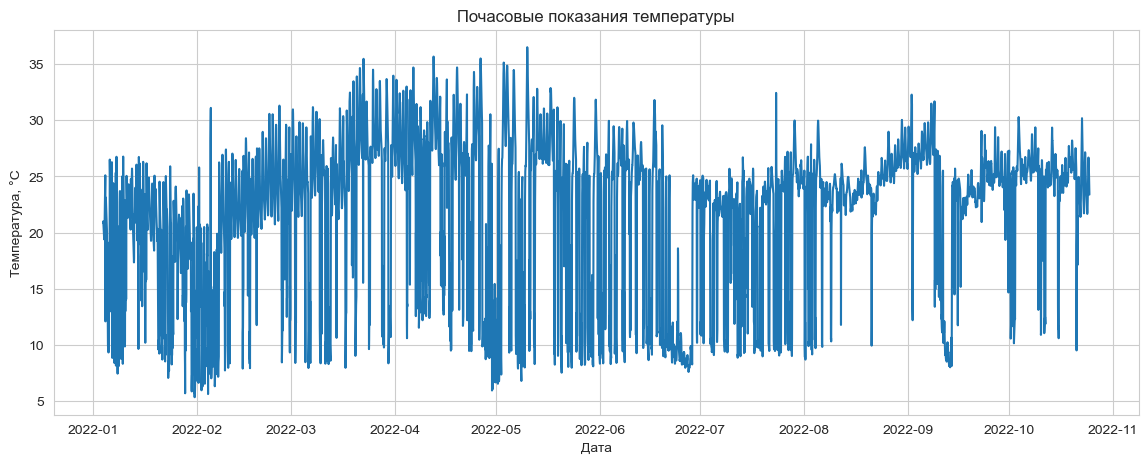

In [4]:
plt.figure(figsize=(14,5))
plt.plot(df.index, df['temp'])
plt.title('Почасовые показания температуры')
plt.xlabel('Дата')
plt.ylabel('Температура, °C')
plt.grid(True)
plt.show()

In [5]:
pval = adfuller(df['temp'])[1]
print(f"\nADF p-value = {pval:.4f} → {'стационарен' if pval < 0.05 else 'нестационарен'}")


ADF p-value = 0.0000 → стационарен


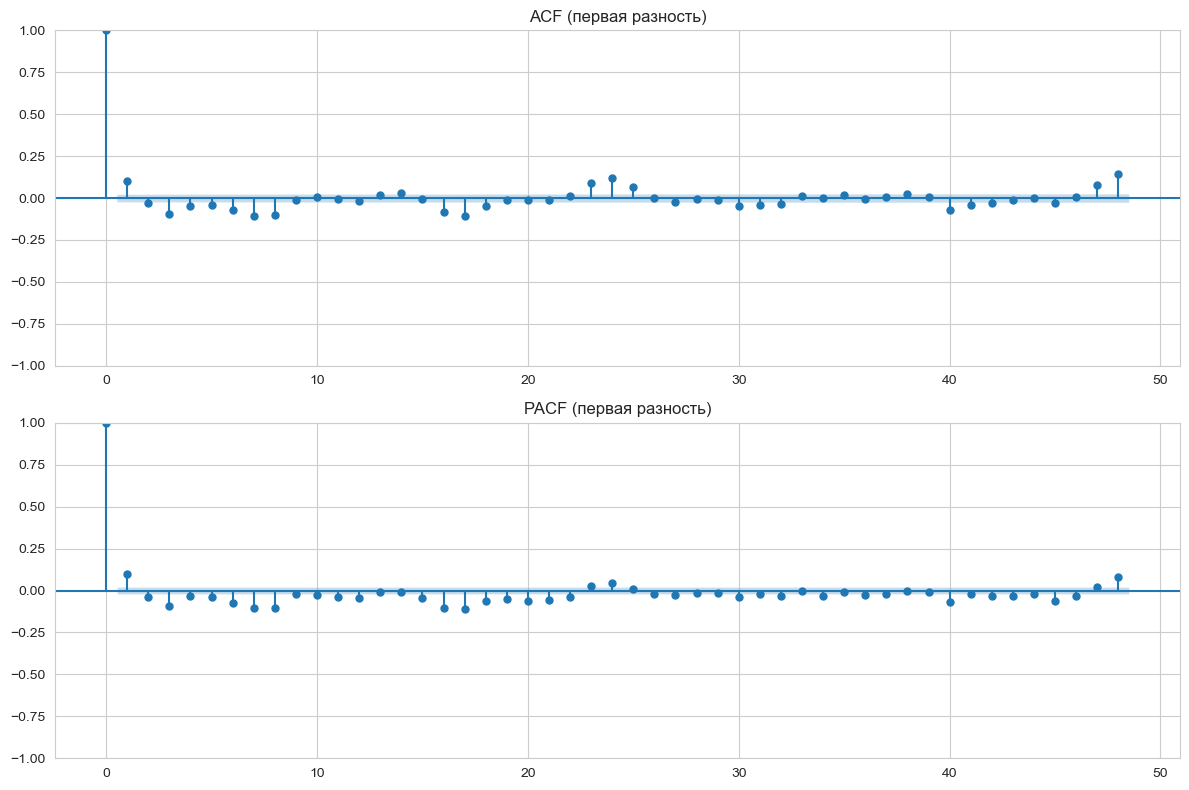

In [6]:
diff = df['temp'].diff().dropna()
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(diff, lags=48, ax=ax1, title='ACF (первая разность)')
plot_pacf(diff, lags=48, ax=ax2, title='PACF (первая разность)')
plt.tight_layout()
plt.show()

In [7]:
train = df.iloc[:3000]
test = df.iloc[3000:]
print(f"Train: {len(train)}, Test: {len(test)}")

Train: 3000, Test: 4056


In [8]:
arima = ARIMA(train['temp'], order=(1, 1, 1))
arima_fit = arima.fit()
print(arima_fit.summary())
pred_arima = arima_fit.forecast(len(test))

                               SARIMAX Results                                
Dep. Variable:                   temp   No. Observations:                 3000
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -7707.280
Date:                Thu, 18 Jun 2026   AIC                          15420.560
Time:                        12:46:17   BIC                          15438.579
Sample:                    01-04-2022   HQIC                         15427.042
                         - 05-08-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0679      0.329     -0.207      0.836      -0.712       0.576
ma.L1          0.1127      0.326      0.346      0.730      -0.526       0.752
sigma2         9.9944      0.115     86.909      0.0

In [9]:
ets = ExponentialSmoothing(train['temp'], trend='add', seasonal='add', seasonal_periods=24).fit()
pred_ets = ets.forecast(len(test))

In [10]:
naive_pred = train['temp'].iloc[-1]
pred_naive = [naive_pred] * len(test)

In [11]:
def score(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAPE': mean_absolute_percentage_error(y_true, y_pred) * 100
    }
metrics = pd.DataFrame({
    'ARIMA(1,1,1)': score(test['temp'], pred_arima),
    'ETS': score(test['temp'], pred_ets),
    'Naive': score(test['temp'], pred_naive)
}).T.round(3)
print("\nМетрики на тестовой выборке:")
print(metrics)
best = metrics['RMSE'].idxmin()
print(f"\nЛучшая модель по RMSE: {best} (RMSE = {metrics.loc[best, 'RMSE']:.3f})")


Метрики на тестовой выборке:
                MAE   RMSE    MAPE
ARIMA(1,1,1)  4.515  7.048  36.360
ETS           4.887  7.082  37.119
Naive         4.514  7.045  36.348

Лучшая модель по RMSE: Naive (RMSE = 7.045)


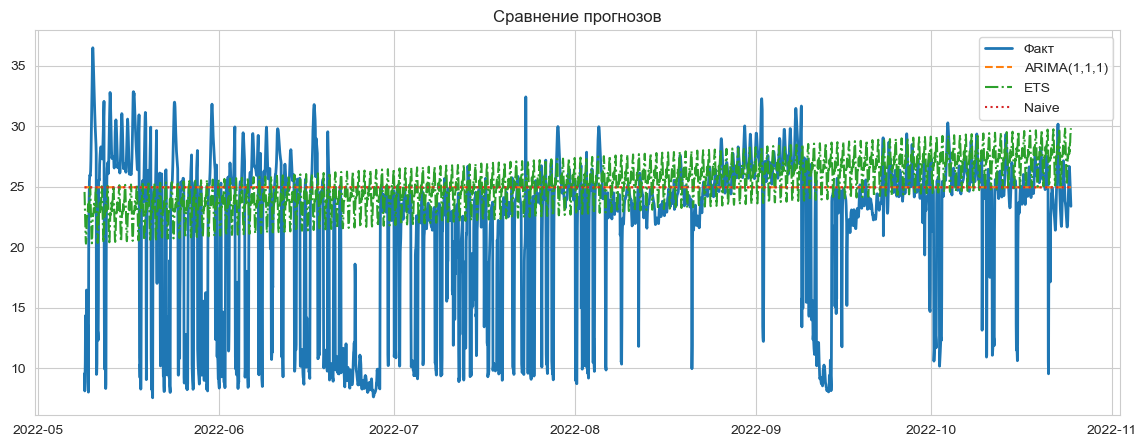

In [12]:
plt.figure(figsize=(14,5))
plt.plot(test.index, test['temp'], label='Факт', linewidth=2)
plt.plot(test.index, pred_arima, '--', label='ARIMA(1,1,1)')
plt.plot(test.index, pred_ets, '-.', label='ETS')
plt.plot(test.index, pred_naive, ':', label='Naive')
plt.legend()
plt.grid(True)
plt.title('Сравнение прогнозов')
plt.show()

# Выводы

Ключевые выводы по задачам.


Ключевые выводы:
- Использована линейная регрессия с признаками: час дня и лаги (1,2,24,25).
- Модель очень быстрая (менее 1 секунды).
- Наивная модель значительно хуже по всем метрикам.
- RMSE выбрана как основная метрика (штрафует большие ошибки).
- Рекомендуется использовать линейную регрессию для быстрого прогноза.
- При необходимости можно увеличить обучающую выборку для улучшения точности.

